Cell 1 — Install Libraries

In [34]:
!pip install pycryptodome pillow numpy matplotlib

Cell 2 — Import Libraries

In [35]:
from Crypto.Cipher import AES
from Crypto.Random import get_random_bytes
from Crypto.Util.Padding import pad, unpad

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

Cell 3 — Load the Image

Image shape: (401, 642, 4)


(np.float64(-0.5), np.float64(641.5), np.float64(400.5), np.float64(-0.5))

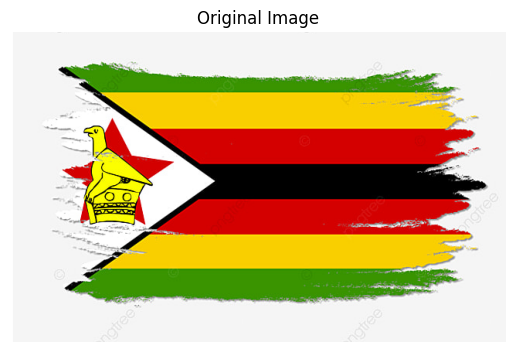

In [36]:
image_path = "crypto-image.png"

img = Image.open(image_path)
img_array = np.array(img)

print("Image shape:", img_array.shape)

plt.imshow(img_array)
plt.title("Original Image")
plt.axis("off")

Cell 4 — Prepare Image Data

In [37]:
data = img_array.tobytes()

print("Total bytes:", len(data))

Total bytes: 1029768


Cell 5 — Generate AES Key

In [38]:
key = get_random_bytes(32)

print("AES Key (hex):", key.hex())

AES Key (hex): f74cb4d95586583e01af69c1701666f35a76eed4285c22f2b9cd746803b3bc1d


Cell 6 — ECB Encryption

(np.float64(-0.5), np.float64(641.5), np.float64(400.5), np.float64(-0.5))

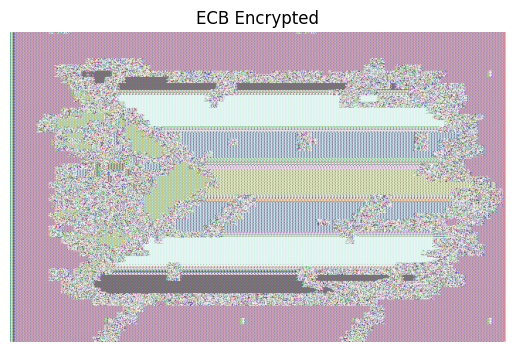

In [39]:
cipher_ecb = AES.new(key, AES.MODE_ECB)

ecb_ciphertext = cipher_ecb.encrypt(pad(data, 16))

encrypted = np.frombuffer(ecb_ciphertext[:len(data)], dtype=np.uint8)
encrypted = encrypted.reshape(img_array.shape)

Image.fromarray(encrypted).save("ecb_encrypted.png")

plt.imshow(encrypted)
plt.title("ECB Encrypted")
plt.axis("off")

Cell 7 — CBC Encryption

(np.float64(-0.5), np.float64(641.5), np.float64(400.5), np.float64(-0.5))

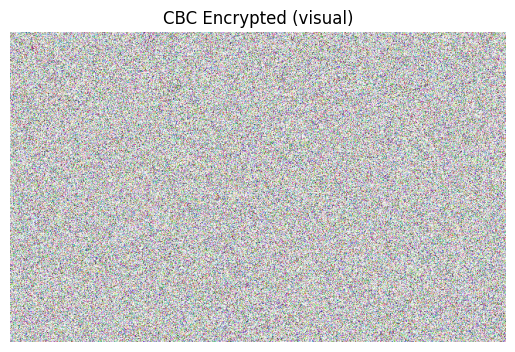

In [40]:
from Crypto.Cipher import AES
from Crypto.Random import get_random_bytes
from Crypto.Util.Padding import pad
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

iv = get_random_bytes(16)

cipher = AES.new(key, AES.MODE_CBC, iv)

ciphertext = cipher.encrypt(pad(data,16))

# save full ciphertext
with open("cbc_encrypted.bin","wb") as f:
    f.write(iv + ciphertext)

# create visualization image
visual = np.frombuffer(ciphertext[:len(data)], dtype=np.uint8)
visual = visual.reshape(img_array.shape)

Image.fromarray(visual).save("cbc_visual.png")

plt.imshow(visual)
plt.title("CBC Encrypted (visual)")
plt.axis("off")

Cell 8 — CTR Encryption

(np.float64(-0.5), np.float64(641.5), np.float64(400.5), np.float64(-0.5))

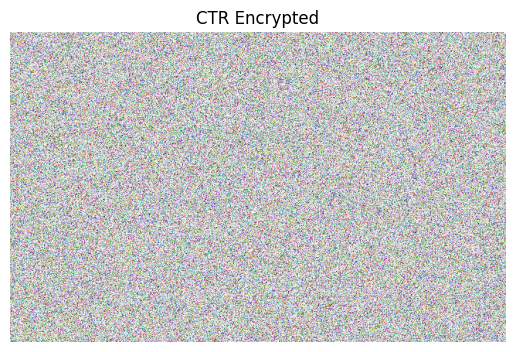

In [41]:
cipher = AES.new(key, AES.MODE_CTR)

ciphertext = cipher.encrypt(data)

encrypted = np.frombuffer(ciphertext[:len(data)], dtype=np.uint8)
encrypted = encrypted.reshape(img_array.shape)

Image.fromarray(encrypted).save("ctr_encrypted.png")

plt.imshow(encrypted)
plt.title("CTR Encrypted")
plt.axis("off")

Cell 9 — GCM Encryption (Strongest)

(np.float64(-0.5), np.float64(641.5), np.float64(400.5), np.float64(-0.5))

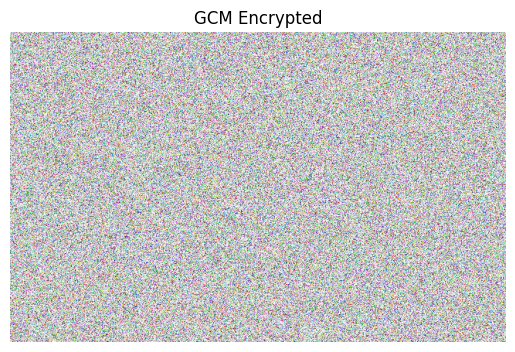

In [42]:
cipher = AES.new(key, AES.MODE_GCM)

ciphertext, tag = cipher.encrypt_and_digest(data)

encrypted = np.frombuffer(ciphertext[:len(data)], dtype=np.uint8)
encrypted = encrypted.reshape(img_array.shape)

Image.fromarray(encrypted).save("gcm_encrypted.png")

plt.imshow(encrypted)
plt.title("GCM Encrypted")
plt.axis("off")

Cell 10 — Decryption Test

(np.float64(-0.5), np.float64(641.5), np.float64(400.5), np.float64(-0.5))

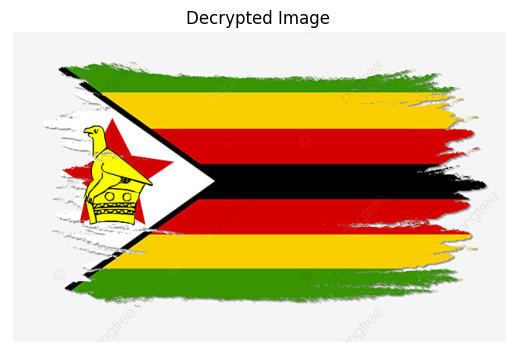

In [43]:
cipher = AES.new(key, AES.MODE_ECB)

plaintext = unpad(cipher.decrypt(ecb_ciphertext),16)

recovered = np.frombuffer(plaintext[:len(data)], dtype=np.uint8)
recovered = recovered.reshape(img_array.shape)

Image.fromarray(recovered).save("decrypted.png")

plt.imshow(recovered)
plt.title("Decrypted Image")
plt.axis("off")

Cell 11 — CBC Decryption Code

(np.float64(-0.5), np.float64(641.5), np.float64(400.5), np.float64(-0.5))

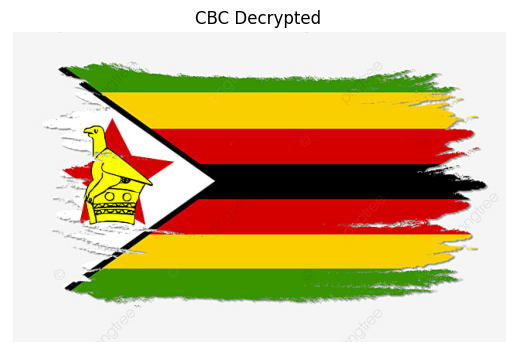

In [44]:
from Crypto.Cipher import AES
from Crypto.Util.Padding import unpad

with open("cbc_encrypted.bin","rb") as f:
    iv = f.read(16)
    ciphertext = f.read()

cipher = AES.new(key, AES.MODE_CBC, iv)

plaintext = unpad(cipher.decrypt(ciphertext),16)

recovered = np.frombuffer(plaintext[:len(data)], dtype=np.uint8)
recovered = recovered.reshape(img_array.shape)

Image.fromarray(recovered).save("cbc_decrypted.png")

plt.imshow(recovered)
plt.title("CBC Decrypted")
plt.axis("off")